In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [6]:
# Define the training data
data1 = np.array([2,3,5,7,9,11,13,15,17,20]).reshape(-1, 1)
data2= np.array([65,70,80,85,95,100,105,110,115,120])

In [7]:
model = LinearRegression()
model.fit(data1,data2)

LinearRegression()

In [8]:
# Get the model parameters
alpha = model.intercept_
beta = model.coef_[0]

print(f"Intercept (α): {alpha:.2f}")
print(f"Slope (β): {beta:.2f}")

Intercept (α): 63.09
Slope (β): 3.08


In [10]:
# Predict for a new value
x_test= np.array([6, 8, 10]).reshape(-1, 1)
y_pred = model.predict(x_test)
print(f"Prediction for x=6: {y_pred[0]:.2f}")

Prediction for x=6: 81.57


In [10]:
import pandas as pd

data = {
    'marla': [5, 7, 10, 12, 15, 20, 25, 30],
    'price_lakhs': [85, 115, 155, 185, 230, 310, 380, 450]
}

df = pd.DataFrame(data)
print("Housing Dataset:")
print(df)

Housing Dataset:
   marla  price_lakhs
0      5           85
1      7          115
2     10          155
3     12          185
4     15          230
5     20          310
6     25          380
7     30          450


In [11]:
# Reshape data for sklearn (X must be 2D)
X = df[['marla']].values  # Independent variable
y = df['price_lakhs'].values  # Dependent variable

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (8, 1)
y shape: (8,)


In [12]:
# Create and train the model
model = LinearRegression()
model.fit(X, y)

# Get the model parameters
alpha = model.intercept_
beta = model.coef_[0]

print("\n=== TRAINED MODEL PARAMETERS ===")
print(f"Intercept (α): {alpha:.2f} lakhs")
print(f"Slope (β): {beta:.2f} lakhs per marla")
print(f"\nTrained Model: Price = {alpha:.2f} + {beta:.2f} × Marla")


=== TRAINED MODEL PARAMETERS ===
Intercept (α): 10.37 lakhs
Slope (β): 14.73 lakhs per marla

Trained Model: Price = 10.37 + 14.73 × Marla


In [13]:
# Predict prices for the training data
y_pred = model.predict(X)
df['predicted_price'] = y_pred

# Predict for new marla values
new_marlas = np.array([8, 17, 35]).reshape(-1, 1)
new_predictions = model.predict(new_marlas)

print("\n=== PREDICTIONS FOR NEW PROPERTIES ===")
for marla, price in zip(new_marlas.flatten(), new_predictions):
    print(f"{marla} Marla: {price:.2f} lakhs PKR")


=== PREDICTIONS FOR NEW PROPERTIES ===
8 Marla: 128.24 lakhs PKR
17 Marla: 260.85 lakhs PKR
35 Marla: 526.07 lakhs PKR


In [14]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Create comprehensive housing dataset
data = {
    'marla': [5, 7, 10, 12, 15, 20, 25, 30, 8, 12, 18, 22, 28, 6, 14, 24],
    'bedrooms': [2, 3, 3, 3, 4, 4, 5, 5, 3, 3, 4, 4, 5, 2, 3, 4],
    'bathrooms': [2, 2, 3, 3, 3, 4, 4, 5, 2, 3, 3, 4, 4, 2, 3, 4],
    'location_score': [6, 7, 8, 6, 7, 8, 9, 9, 5, 7, 8, 7, 9, 6, 7, 8],
    'price_lakhs': [85, 115, 155, 175, 230, 310, 380, 450, 105, 185, 265, 325, 420, 90, 200, 350]
}

df = pd.DataFrame(data)
print("COMPREHENSIVE HOUSING DATASET:")
print(df)
print(f"\nDataset shape: {df.shape}")

COMPREHENSIVE HOUSING DATASET:
    marla  bedrooms  bathrooms  location_score  price_lakhs
0       5         2          2               6           85
1       7         3          2               7          115
2      10         3          3               8          155
3      12         3          3               6          175
4      15         4          3               7          230
5      20         4          4               8          310
6      25         5          4               9          380
7      30         5          5               9          450
8       8         3          2               5          105
9      12         3          3               7          185
10     18         4          3               8          265
11     22         4          4               7          325
12     28         5          4               9          420
13      6         2          2               6           90
14     14         3          3               7          200
15     24

=== DATASET SUMMARY ===
           marla   bedrooms  bathrooms  location_score  price_lakhs
count  16.000000  16.000000  16.000000       16.000000    16.000000
mean   16.000000   3.562500   3.187500        7.312500   240.000000
std     8.082904   0.963933   0.910586        1.195478   120.415946
min     5.000000   2.000000   2.000000        5.000000    85.000000
25%     9.500000   3.000000   2.750000        6.750000   145.000000
50%    14.500000   3.500000   3.000000        7.000000   215.000000
75%    22.500000   4.000000   4.000000        8.000000   331.250000
max    30.000000   5.000000   5.000000        9.000000   450.000000

=== CORRELATION MATRIX ===
price_lakhs       1.000000
marla             0.997969
bathrooms         0.954561
bedrooms          0.944809
location_score    0.842859
Name: price_lakhs, dtype: float64


<Figure size 1500x1000 with 0 Axes>

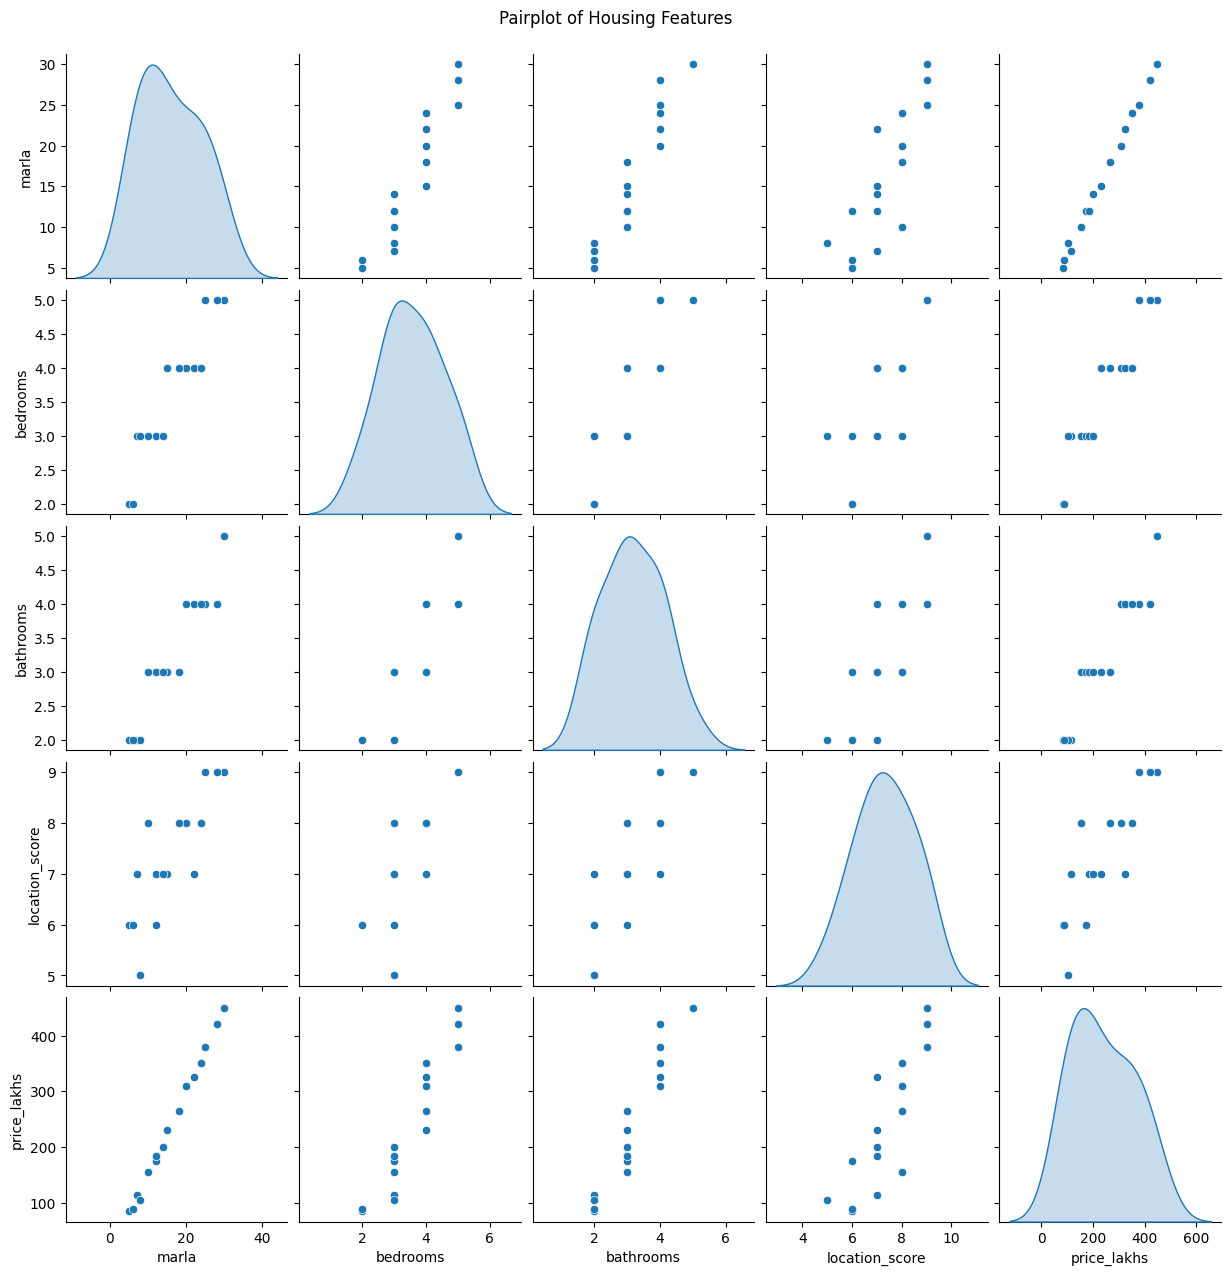

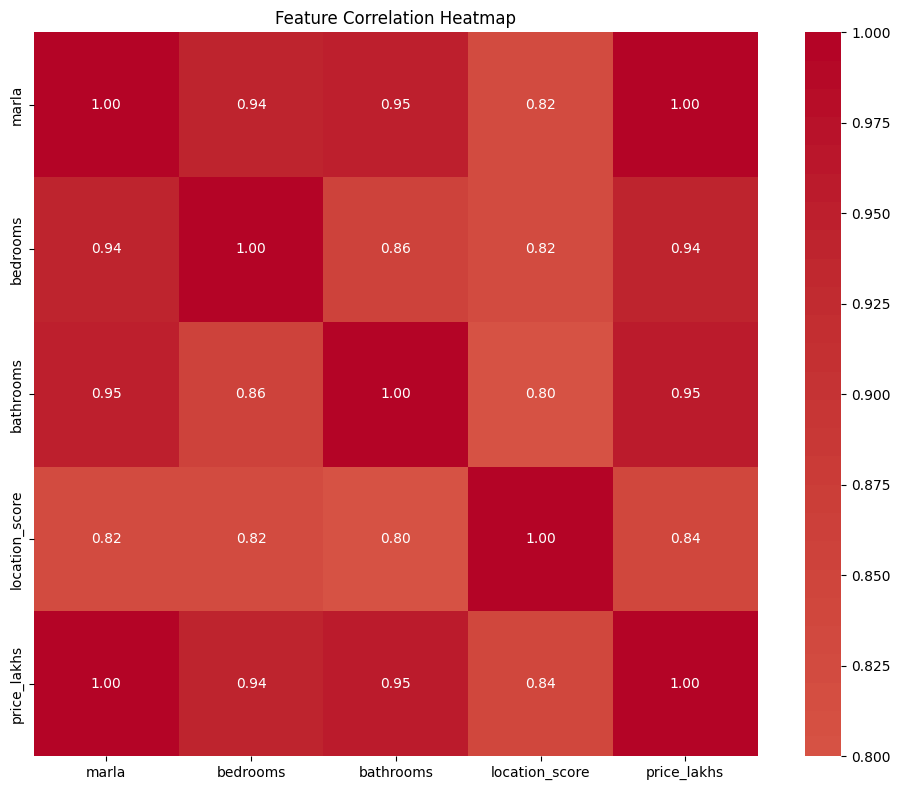

In [15]:
# Explore the data
print("=== DATASET SUMMARY ===")
print(df.describe())

print("\n=== CORRELATION MATRIX ===")
correlation_matrix = df.corr()
print(correlation_matrix['price_lakhs'].sort_values(ascending=False))

# Visualization
plt.figure(figsize=(15, 10))

# Pairplot to see relationships
sns.pairplot(df, diag_kind='kde')
plt.suptitle('Pairplot of Housing Features', y=1.02)
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [16]:
# Separate features and target variable
X = df[['marla', 'bedrooms', 'bathrooms', 'location_score']]
y = df['price_lakhs']

print("=== FEATURES (X) ===")
print(X.head())
print(f"\nFeatures shape: {X.shape}")

print("\n=== TARGET (y) ===")
print(y.head())
print(f"Target shape: {y.shape}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n=== DATA SPLIT ===")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

=== FEATURES (X) ===
   marla  bedrooms  bathrooms  location_score
0      5         2          2               6
1      7         3          2               7
2     10         3          3               8
3     12         3          3               6
4     15         4          3               7

Features shape: (16, 4)

=== TARGET (y) ===
0     85
1    115
2    155
3    175
4    230
Name: price_lakhs, dtype: int64
Target shape: (16,)

=== DATA SPLIT ===
Training set: 12 samples
Testing set: 4 samples


In [17]:
# Create and train the multiple linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Get model parameters
alpha = model.intercept_
betas = model.coef_

print("=== TRAINED MULTIPLE LINEAR REGRESSION MODEL ===")
print(f"Intercept (α): {alpha:.2f} lakhs")
print("\nFeature Coefficients (β):")
for feature, coef in zip(X.columns, betas):
    print(f"  {feature:15}: {coef:7.2f} lakhs")

print(f"\nModel Equation:")
equation = f"Price = {alpha:.2f}"
for feature, coef in zip(X.columns, betas):
    equation += f" + {coef:.2f}×{feature}"
print(equation)

=== TRAINED MULTIPLE LINEAR REGRESSION MODEL ===
Intercept (α): -49.25 lakhs

Feature Coefficients (β):
  marla          :   13.09 lakhs
  bedrooms       :    4.78 lakhs
  bathrooms      :    7.21 lakhs
  location_score :    5.27 lakhs

Model Equation:
Price = -49.25 + 13.09×marla + 4.78×bedrooms + 7.21×bathrooms + 5.27×location_score


In [18]:
# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Add predictions to dataframe
df_train = X_train.copy()
df_train['actual_price'] = y_train
df_train['predicted_price'] = y_train_pred
df_train['error'] = df_train['predicted_price'] - df_train['actual_price']

print("=== PREDICTIONS ON TRAINING DATA ===")
print(df_train.head(8))

# Model evaluation
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\n=== MODEL PERFORMANCE ===")
print("Training Set:")
print(f"  R²: {train_r2:.4f}")
print(f"  MSE: {train_mse:.2f}")
print(f"  RMSE: {np.sqrt(train_mse):.2f} lakhs")

print("\nTesting Set:")
print(f"  R²: {test_r2:.4f}")
print(f"  MSE: {test_mse:.2f}")
print(f"  RMSE: {np.sqrt(test_mse):.2f} lakhs")

=== PREDICTIONS ON TRAINING DATA ===
    marla  bedrooms  bathrooms  location_score  actual_price  predicted_price  \
13      6         2          2               6            90        84.896332   
11     22         4          4               7           325       323.524090   
8       8         3          2               5           105       110.571350   
9      12         3          3               7           185       180.676859   
2      10         3          3               8           155       159.780896   
15     24         4          4               8           350       354.969606   
4      15         4          3               7           230       224.712023   
7      30         5          5               9           450       450.750133   

       error  
13 -5.103668  
11 -1.475910  
8   5.571350  
9  -4.323141  
2   4.780896  
15  4.969606  
4  -5.287977  
7   0.750133  

=== MODEL PERFORMANCE ===
Training Set:
  R²: 0.9989
  MSE: 15.23
  RMSE: 3.90 lakhs

Testing Set